In [1]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install imbalanced-learn
!{sys.executable} -m pip install seaborn



In [2]:
import sys, pandas as pd
print(sys.executable)
print(pd.__version__)

/Users/oliviaespineiraflores/miniforge3/bin/python
2.3.3


In [3]:
import sys
print(sys.executable)

/Users/oliviaespineiraflores/miniforge3/bin/python


## Task 1: Identify Prediction and Target Variables

**Lecture Material:**
- Lecture 1 — *Problem Formulation*
- Lecture 2 — *Data Inspection*

---

### 1. Inspect the Dataset and Select the Target Variable

- Inspect the dataset and identify which column should be treated as the **target variable** for this assignment.

---

### 2. Justify the Prediction Objective

- Explain why the selected column represents the appropriate **prediction objective** in the context of the marketing campaign.
- Clearly connect your choice to the campaign’s business objective (e.g., conversion, customer response, revenue generation).

---

### 3. Identify and Reject Alternative Target Variables

- Identify **at least two other variables** that might appear to be valid prediction targets.
- For each variable:
  - Explain why it may initially seem appropriate.
  - Explain why it should **not** be treated as the prediction objective.



Given the situation. It can be determined that this is a classification problem since we are predicting whether the client will subscribe to a specific deposit.

Given the data. It can be determined that the "y" column is the target column since it responds directly to the question: "has the client subscribed to the term deposit". This is a binary value meaning only 2 possible outcomes. Making this a perfect target for logistic regression.

Another variable that might be seen as the target is the "poutcome" that specifies the outcome of the previous marketing campaign. One might believe this is the target since it also responds to the same question, the only issue is that at the time of taking the decision, we already know this output, hence we don't really want to predict it.

Finally, a variable that might lead to data leakage is that of "duration", this attribute highly affects the output of the duration and once the call is made, it is known whether the client will subscribe to the term deposit, providing no actual meaningful decision knowledge. Therefore, "this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model".

## Task 2: Data Loading and Exploration
- Load the dataset into a Pandas DataFrame
- Inspect the structure of the dataset: number of observations, number of features, data types and basic summary statistics.
- Identify which variables are numerical and which are categorical
- Analyze the distribution of the target variable and comment on potential class imbalance.
- Detect explicit and implicit missing values (e.g., special categories such as unknown).
- Visualize the distribution of at least:
–- two numerical variables; and
–- two categorical variables.
- Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.


Note: Exploratory analysis is not a checklist of plots. Each visualization or statistic should support a specific
observation or hypothesis about the data.

This is done before any operation learns from data but before we split the dataset to really understand the underlying distributions of the different variables.

In [4]:
import pandas as pd

In [5]:
#printing out the first 15 elements
df = pd.read_csv('bank-additional.csv', sep=';')
print(df.head(15))

    age            job   marital            education  default  housing  \
0    30    blue-collar   married             basic.9y       no      yes   
1    39       services    single          high.school       no       no   
2    25       services   married          high.school       no      yes   
3    38       services   married             basic.9y       no  unknown   
4    47         admin.   married    university.degree       no      yes   
5    32       services    single    university.degree       no       no   
6    32         admin.    single    university.degree       no      yes   
7    41   entrepreneur   married    university.degree  unknown      yes   
8    31       services  divorced  professional.course       no       no   
9    35    blue-collar   married             basic.9y  unknown       no   
10   25       services    single             basic.6y  unknown      yes   
11   36  self-employed    single             basic.4y       no       no   
12   36         admin.   

In [6]:
#maybe splitting the dataset is better to do before.

print("Shape:", df.shape)
print("\nData types:", df.dtypes)
print("\nSummary Statistics:", df.describe())



Shape: (4119, 21)

Data types: age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Summary Statistics:                age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000

the shape tells us there are 4119 rows and 21 columns (20 features and 1 target).

Furthermore, these statistics also display signs of skewness in age, duration campaign, pdays anf previous where the mean tends to exceed the median meaning a possible right skew. In addition, pdays is dominated by 999 which we infer is a special encoding for "not previously contacted"

In [7]:
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(include='object').columns.tolist()

print("Numerical variables:", numerical)
print("\nCategorical variables:", categorical)

Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


y
no     3668
yes     451
Name: count, dtype: int64

Class balance (%):
 y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


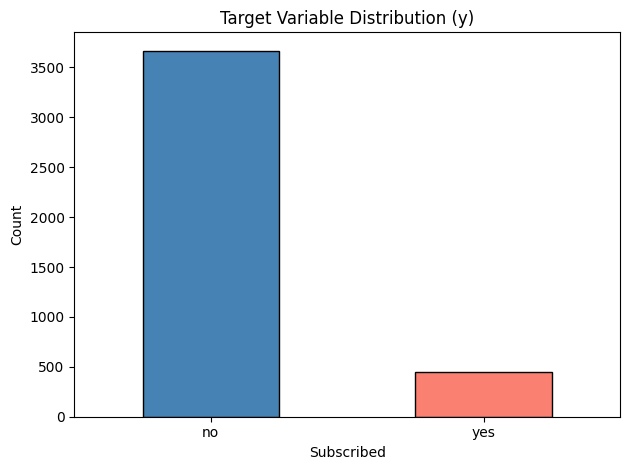

In [8]:
#Now we are going to loot at the target variable distribution to look at class imbalance.
import matplotlib.pyplot as plt

counts = df['y'].value_counts()
print(counts)
print("\nClass balance (%):\n", df['y'].value_counts(normalize=True) * 100)

counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Takes these into account when separating the dataset.

Now we also want to understand which variables are missing:

In [9]:
print("Explicit nulls:\n", df.isnull().sum())

# Implicit missing values encoded as 'unknown'
print("\nImplicit missing values ('unknown'):")
for col in categorical:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")

Explicit nulls:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


Here we see that there are no explicit missing values but there are implicit.
Implicit missing variables might be an issue for education, housing, loan (<5%) and especially default.

The value of "unknowns" for default is too high so we cannot drop the variables, better to use it as a different category.

In this case, no records will be dropped off from the dataset since the value of the missing is too small to be significant.

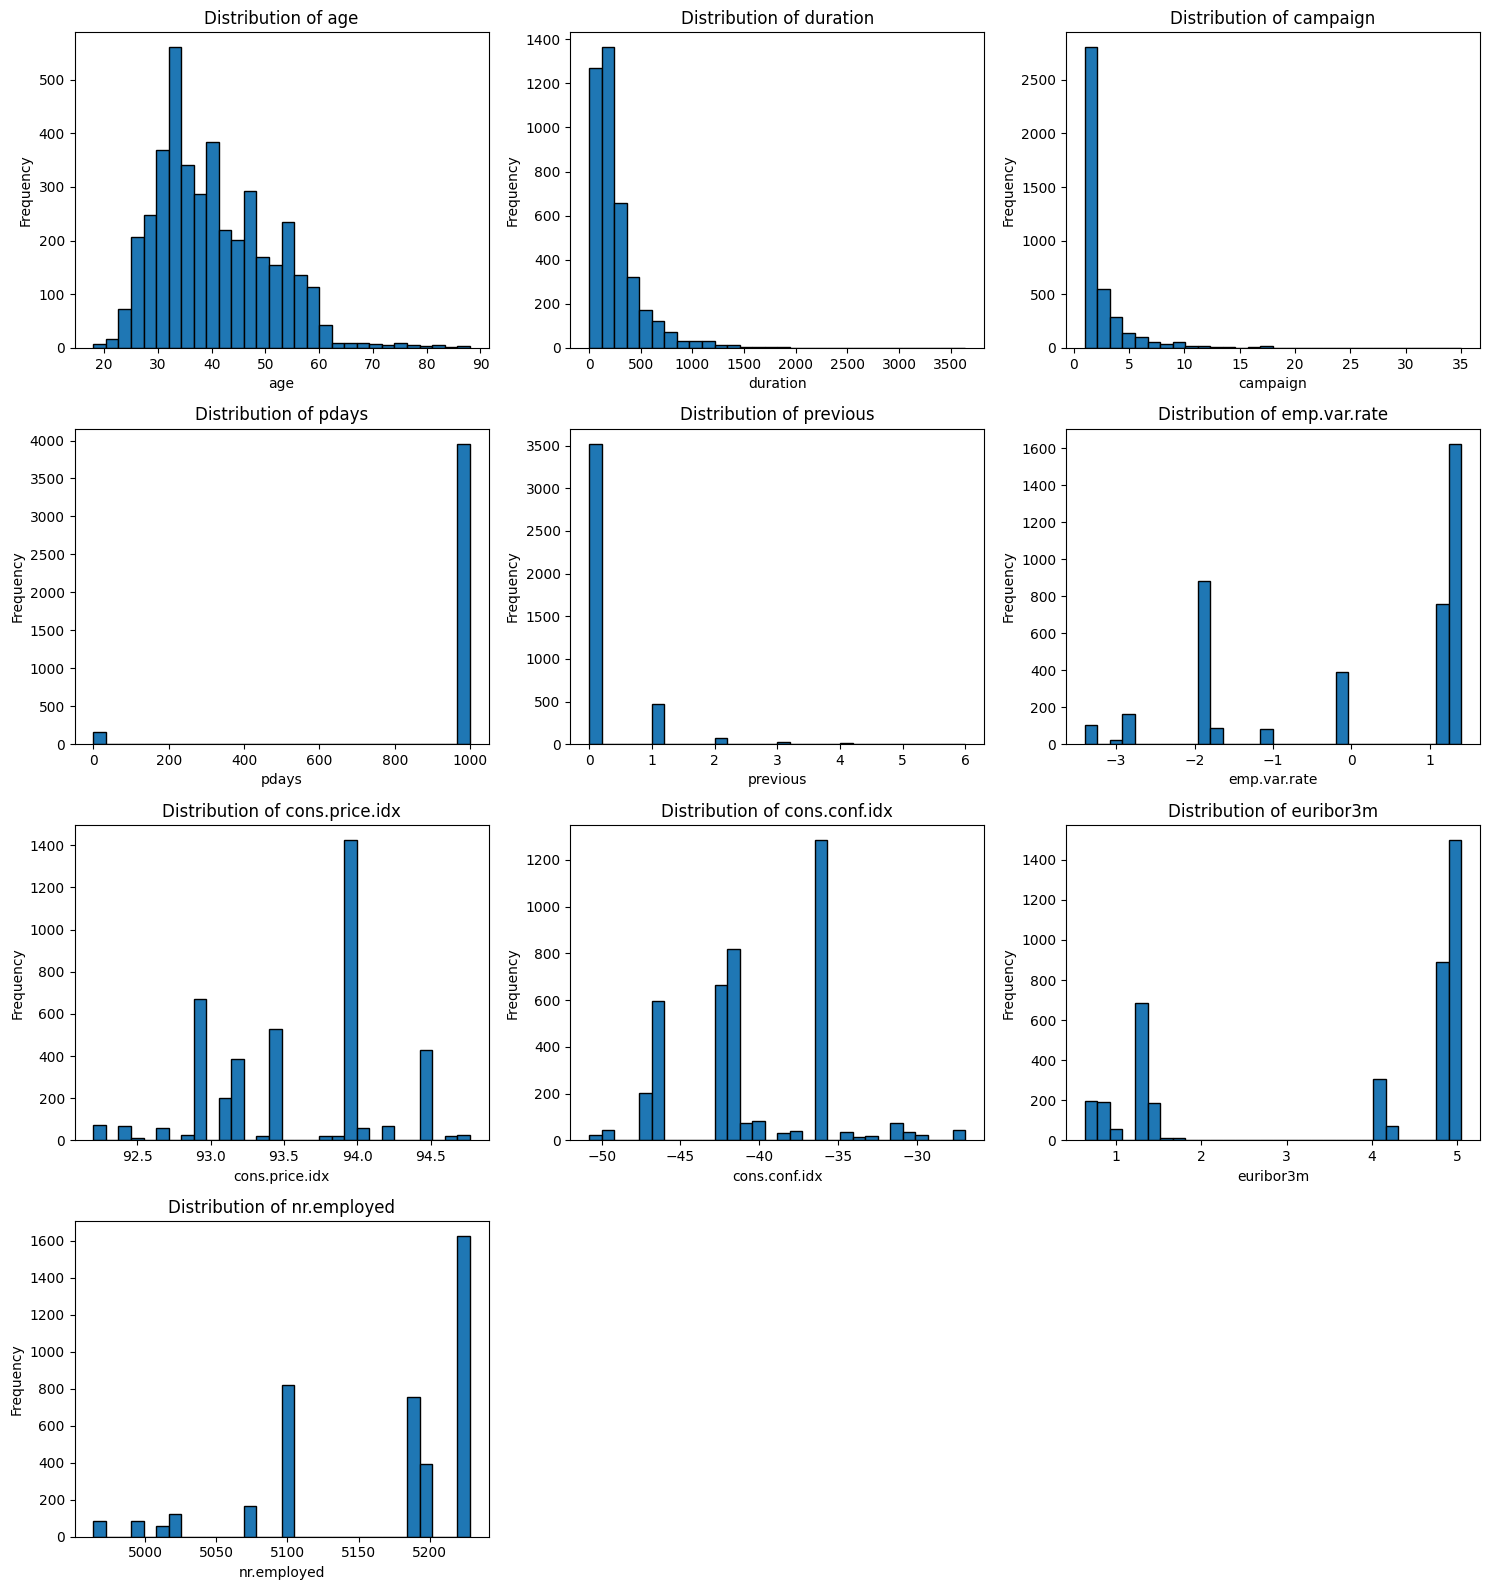

In [10]:
import math
# here we investigate two of the numerical values age and duration
#Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

numerical_vars= ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n_variables= len(numerical_vars)

cols=3
rows= math.ceil(n_variables/cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_vars):
    df[col].plot(
        kind='hist',
        bins=30,
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

It is important that we consider the skewness of duration, campaign previous and pdays. This might affect the results.

In [11]:
#now we do the same but for categorical values:

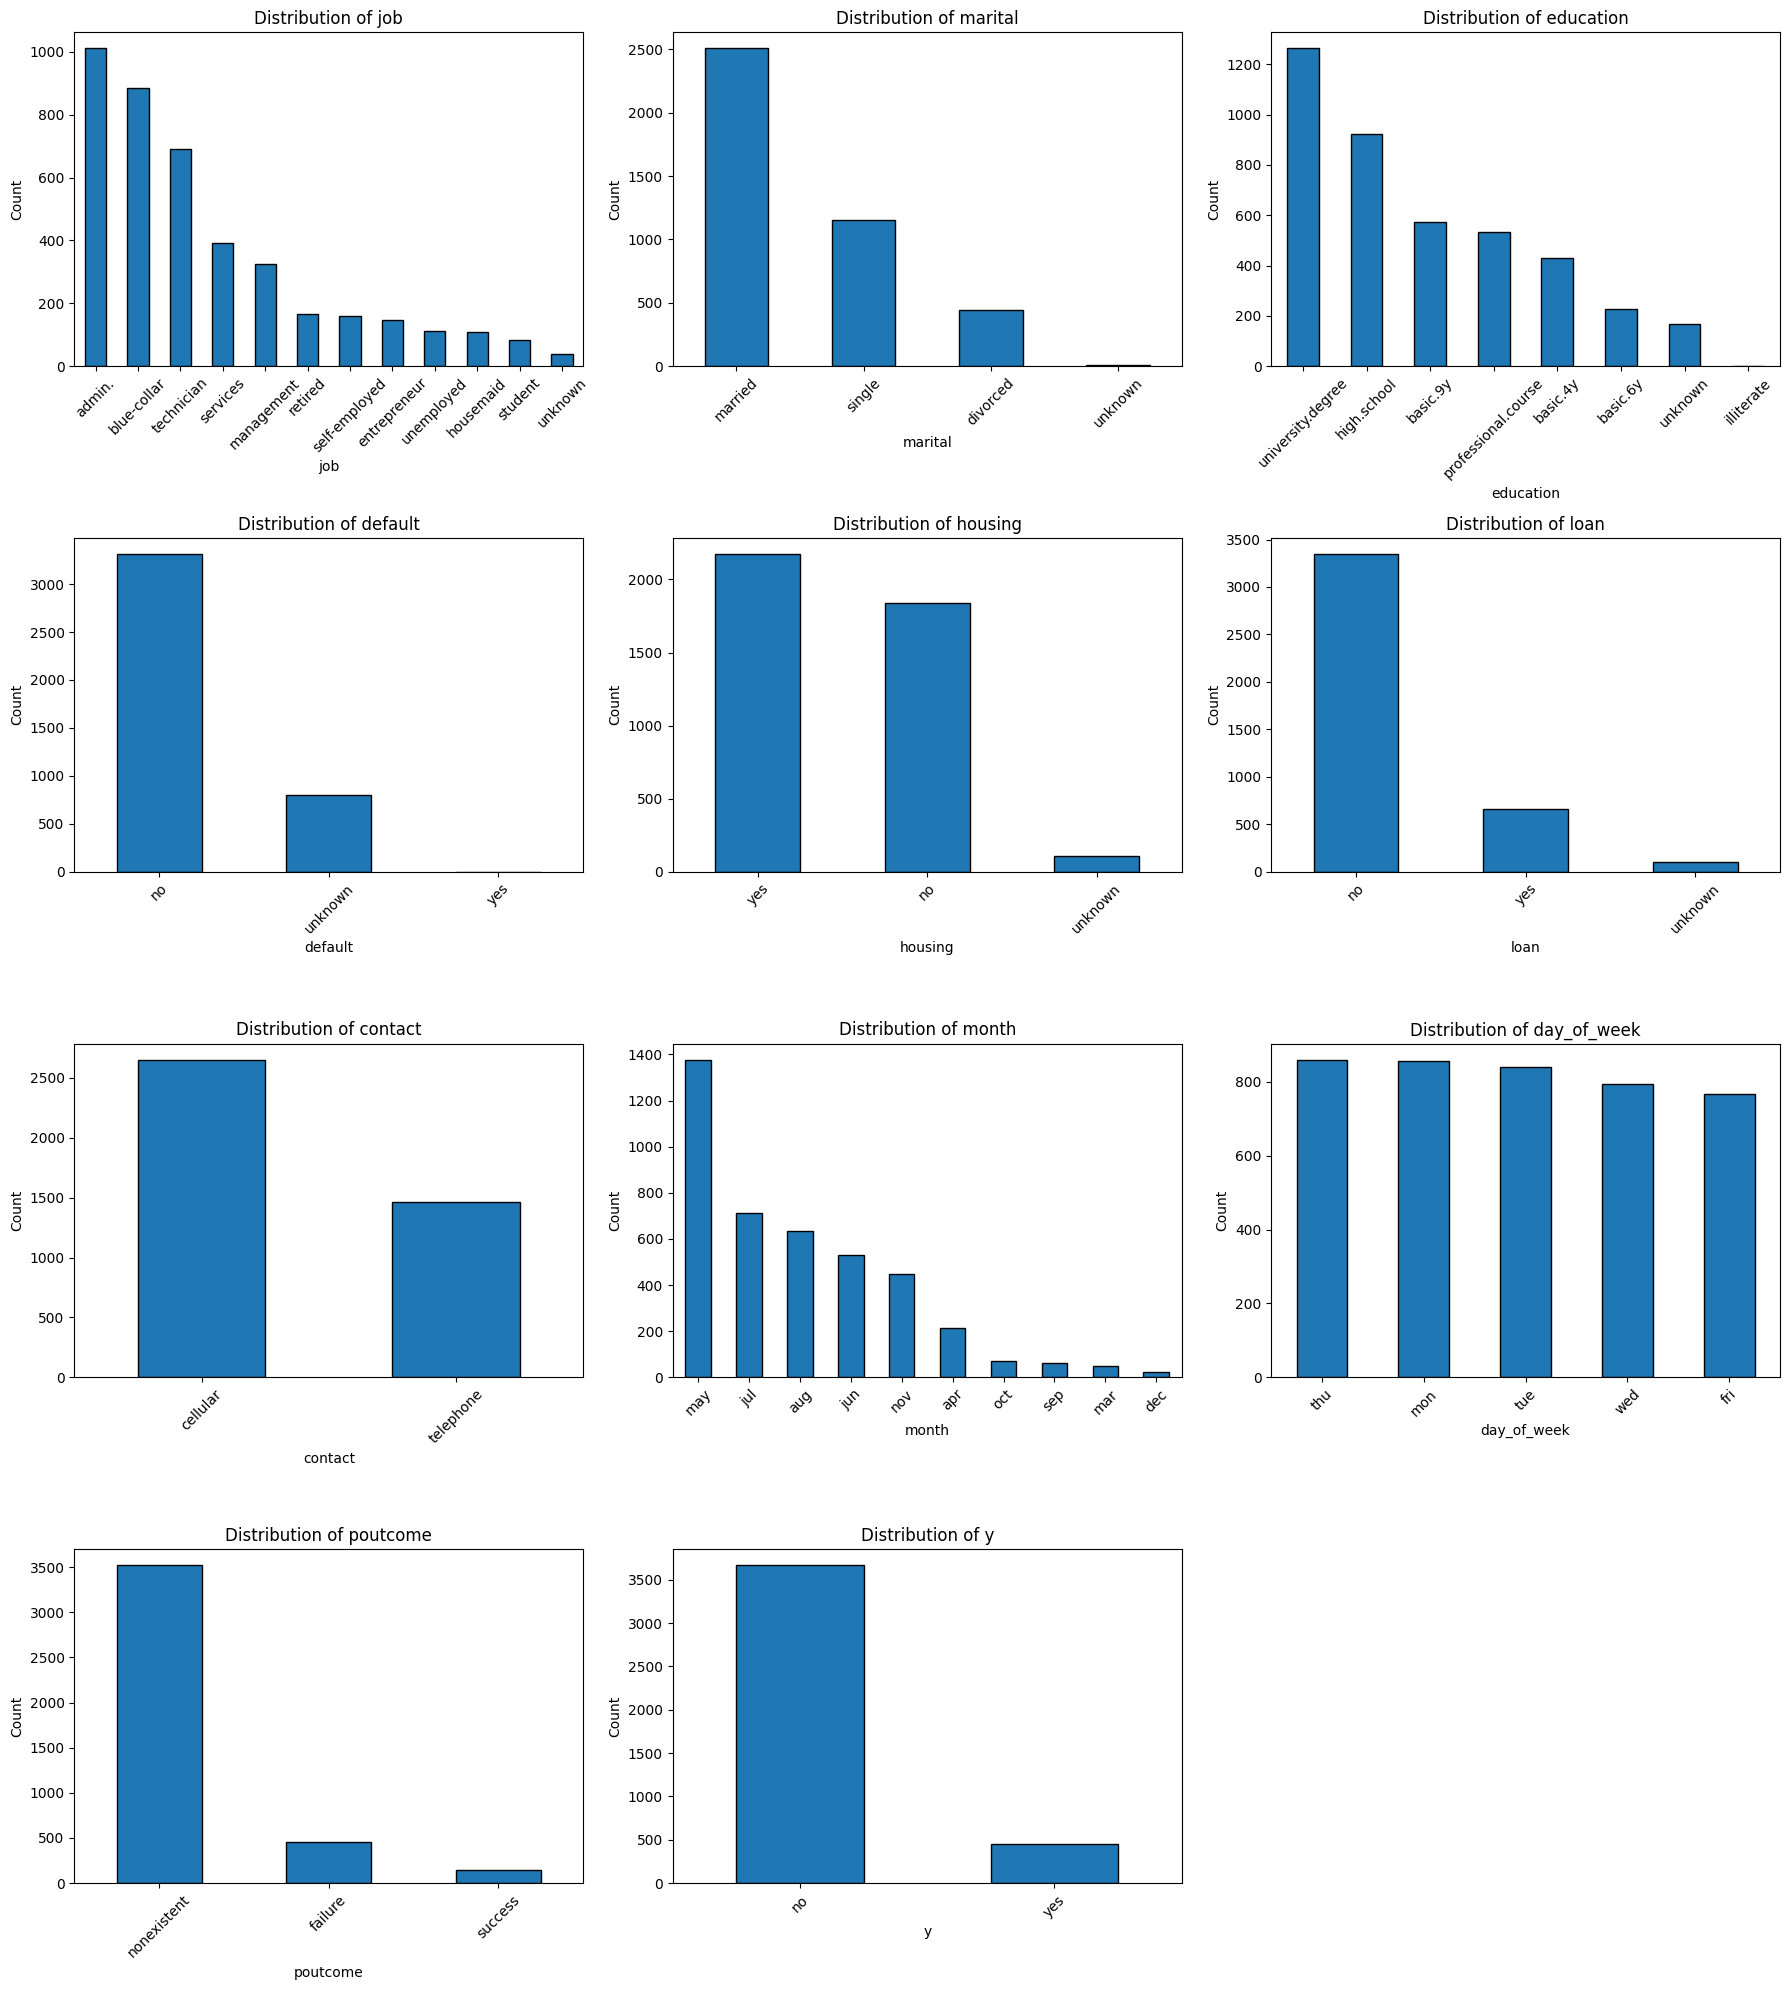

In [12]:
import matplotlib.pyplot as plt
import math

categorical_vars = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week',
    'poutcome', 'y'
]

n = len(categorical_vars)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From these graphs we can see there is a great class imbalance, for default, most of the values are "no". This low variance may lead to low predictive power.

Other categories that also have imbalance are:
- marital status
- job
- education
- month
- poutcome
- y

As aforementioned, the variable that requires special attention is duration. This is because it is highly right skewed and contains extreme values. Nevertheless, the main thing that should trigger response is the fact that once we know the duration of the call, we know whether the client has or hasnt taken the deposit.

Because of this analysis the only column that will be dropped will be duration.

In [13]:
df = df.drop(columns=['duration'])
X = df.drop('y', axis=1)
y = df['y']

## Step 3: Data Splitting.
Lecture material: Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline). LECTURE 8
- Split the dataset into training, validation, and test sets.
- Justify your choice of proportions for each split.
- Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset.
- Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage would arise if splitting were performed later.

Note: A recommended strategy is to first split the dataset into a training set and a temporary set, and then


split the temporary set into validation and test sets. Use the stratify argument of train test split where
appropriate.

This has to be done before any operation that learns from data.
It is also always done before steps that compute distributional statistics, e.g., feature scaling, imputation, encoding,
feature selection, dimensionality reduction, model training (SESSION 8)

In this case, stratification is important since many of the classes seem to be unbalanced. Therefore, we will use stratified splitting on 'y' preserving class proportions in the split sets.

In [14]:
import sys
!{sys.executable} -m pip install scikit-learn

In [15]:
from sklearn.model_selection import train_test_split

#Here we are doing the first split. for obtaining the training and test 60% and 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

#now for the test we split in 50% for the validation set. Meaning the data is split into 60% (training) 20%(testing) and 20% (validation).

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% of 40% = 20%
    stratify=y_temp,
    random_state=42
)

print(f"Train:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")

Train:      2471 rows
Validation: 824 rows
Test:       824 rows


Explanation for this step:
Here I have split the data into 60% for training, 20% for testing and the other 20% for validation. This was implemented using a two step stratified split: first, the dataset was split into training(60%) and a temporary set(40%)and then the temporary set was split equally into validation (20%) and test(20%) sets.

The training set has the largest proportion of data so the model parameters are learned exclusively from this data. In other words, a larger training set allows for an improved parameter stability and reduces variance.

The validation and test sets must be large enough to reliably estimate performance and support model adjustments.
Overall, this split has been selected to optimise learning capacity whilst maintaining enough data to make sure the model is reliable.


Furthermore, stratified splitting was performed with respect to the target variable to endure that the proportion of each class (if they subscribed or didn't) is preserved across training, validation and test sets. This is essential because there is quite an imbalance in the target variables that could lead the subset to be disproportionate which would then influence the accuracy, precision and recall making them unreliable.

The data has been split before any preprocessing steps to prevent from data leakage. If this is done at a later stage there could arise group leakage.

STEP 4: MANAGING MISSING VALUES
Task: Managing Missing Values
Lecture material: Lecture 2 (Data Inspection), Lecture 5 (Preprocessing and Pipeline Discipline).
• Identify both explicit missing values (e.g., NaN) and implicit missing values (e.g., categories such as unknown
or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements).
• Quantify the extent of missingness for each affected variable.
• Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate
category, indicator variable).
• Clearly state which operations must be fitted using the training set only, and explain why.
Note: Your strategy should distinguish between “data cleaning” decisions (e.g., correcting inconsistent entries)
and “modeling” decisions (e.g., whether missingness itself may carry predictive information)

Now we focus on the categorical columns.

In [16]:
#Some was done before but we will repeat and delve into it more in this segment
#checking for explicit variables
# Explicit missing values (NaN) — TRAIN ONLY
missing_count = X_train.isna().sum()
missing_pct = (X_train.isna().mean() * 100).round(2)

print("Explicit missing values (count) — X_train:")
print(missing_count[missing_count > 0])

print("\nExplicit missing values (%) — X_train:")
print(missing_pct[missing_pct > 0])

Explicit missing values (count) — X_train:
Series([], dtype: int64)

Explicit missing values (%) — X_train:
Series([], dtype: float64)


In [17]:
#Now looking at the implicit variables
cat_cols = X_train.select_dtypes(include="object").columns

unknown_count = (X_train[cat_cols] == "unknown").sum().sort_values(ascending=False)
unknown_pct = ((X_train[cat_cols] == "unknown").mean() * 100).round(2)

report = unknown_count.to_frame("unknown_count").join(unknown_pct.to_frame("unknown_%"))
print("\nImplicit missingness encoded as 'unknown' — X_train:")
print(report[report["unknown_count"] > 0])


Implicit missingness encoded as 'unknown' — X_train:
           unknown_count  unknown_%
default              492      19.91
education            104       4.21
housing               55       2.23
loan                  55       2.23
job                   20       0.81
marital                7       0.28


The dataset contains no explicit missing values (NaN). However, several categorical variables contain the value "unknown", which represents implicit missingness.

The extent of implicit missingness in the training set is as follows:
- marital: 7 (0.28%)
- default: 492 (19.9%)
- housing: 55 (2.23%)
- education: 104 (4.21%)
- loan: 55 (2.23%)
- job: 20 (0.81%)

The fact that the database contains unknown information could be due to the client not sharing this information and therefore might be informative for the prediction, therefore these "unknown" variables can be kept as a category.

Although a missing indicator for default was initially considered, it was ultimately removed. The binary mapping applied during encoding (yes→1, no→0, unknown→-1) already explicitly captures the unknown category as a distinct value, making a separate indicator column redundant. Retaining both would introduce correlation between two columns representing the same information.


I have decided to not use any form of statistical imputation to prevent data leakage. This is done so no parameters that aren't actually represented in the database are learnt in this step.

Now we have to analyse the numerical predictors.

In [18]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(num_cols)

print("\nExplicit missing in numerical columns (TRAIN ONLY):")
print(X_train[num_cols].isna().sum())

Numerical columns:
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Explicit missing in numerical columns (TRAIN ONLY):
age               0
campaign          0
pdays             0
previous          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


In [19]:
import numpy as np

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    print("="*50)
    print(f"Column: {col}")

    series = X_train[col]

    print(f"Min: {series.min()}")
    print(f"Max: {series.max()}")
    print(f"Mean: {series.mean():.2f}")
    print(f"Std: {series.std():.2f}")
    print(f"1st percentile: {np.percentile(series, 1)}")
    print(f"99th percentile: {np.percentile(series, 99)}")

    # Check for common sentinel values
    suspicious_values = [-1, 0, 999, 9999]
    for val in suspicious_values:
        if val in series.values:
            count = (series == val).sum()
            print(f"⚠ Value {val} appears {count} times ({count/len(series)*100:.2f}%)")

    # Show top 5 largest values
    print("Top 5 largest values:")
    print(series.sort_values(ascending=False).head())

    # Show bottom 5 smallest values
    print("Bottom 5 smallest values:")
    print(series.sort_values().head())

Column: age
Min: 18
Max: 86
Mean: 40.12
Std: 10.32
1st percentile: 24.0
99th percentile: 68.30000000000018
Top 5 largest values:
696     86
1123    85
150     82
3549    82
338     81
Name: age, dtype: int64
Bottom 5 smallest values:
477     18
899     18
1377    20
200     21
1510    21
Name: age, dtype: int64
Column: campaign
Min: 1
Max: 35
Mean: 2.57
Std: 2.68
1st percentile: 1.0
99th percentile: 14.0
Top 5 largest values:
2552    35
3564    29
3241    29
56      27
2988    23
Name: campaign, dtype: int64
Bottom 5 smallest values:
3951    1
1354    1
2196    1
3740    1
3177    1
Name: campaign, dtype: int64
Column: pdays
Min: 0
Max: 999
Mean: 957.60
Std: 198.55
1st percentile: 3.0
99th percentile: 999.0
⚠ Value 0 appears 2 times (0.08%)
⚠ Value 999 appears 2368 times (95.83%)
Top 5 largest values:
1802    999
4059    999
2020    999
2573    999
2631    999
Name: pdays, dtype: int64
Bottom 5 smallest values:
3127    0
1046    0
1022    1
3665    1
405     2
Name: pdays, dtype: int64

Here we can see that pdays goes from 0 to 999. In this case 999 is understood as the client not being previously contacted, the rest can be understood as the amount of days since last contact. To work with this value, we will treat it as a different category and not an actual value.

In [20]:
# Create binary indicator for never contacted
X_train["pdays_never_contacted"] = (X_train["pdays"] == 999).astype(int)
X_val["pdays_never_contacted"] = (X_val["pdays"] == 999).astype(int)
X_test["pdays_never_contacted"] = (X_test["pdays"] == 999).astype(int)

In [21]:
#changing the values here for numeric recency
X_train.loc[X_train["pdays"] == 999, "pdays"] = 0
X_val.loc[X_val["pdays"] == 999, "pdays"] = 0
X_test.loc[X_test["pdays"] == 999, "pdays"] = 0

For the numerical variables, no explicit NaN values were detected. However, the variable pdays contains the value 999 in 95.83% of training examples. In this dataset, 999 encodes “client was not previously contacted” and does not represent a genuine numeric measurement.

This is not true missingness, but structural encoding. Therefore:
- A binary indicator variable (never_contacted) was created to capture this condition.
- The numeric interpretation of pdays is preserved for clients who were previously contacted.

All other numerical variables exhibit realistic ranges and do not contain sentinel values such as -1 or 999. Therefore, no further intervention was required.



In this case, no statistical imputation (mean, median or mode) was performed. Nevertheless if we were to include it, the statistics would be performed solely in the training dataset to avoid data leakage. If it had been done, it should only be applied to the training set to avoid data leakage.

Finally, no rows were dropped. Although missingness was negligible for some variables (e.g., marital and job), it was moderate for other, particularly default (20%). Dropping these rows would have caused significant data loss and potential bias, so "unkown" was retained as an explicit category. For pdays, the value 999 is not true missingness but a sentinel indicating the client was never previously contacted; this was managed by engineering a binary flag (pdays_never_contacted) and setting the numerical value to 0.


Task 5: Encoding Categorical Variables

Lecture material: Lecture 4 (Categorical Encoding), Lecture 6 (Linear Models), Lecture 9 (Feature Engineering
and Expressiveness).
• Identify all categorical variables in the dataset.
• Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables
(categories with a meaningful order, e.g., education level), and justify your classification.
• Select and apply an appropriate encoding strategy for each categorical variable.
• Clearly state which encoders must be fitted on the training set only, and explain why.
• Analyze how encoding changes:
– the dimensionality of the dataset;
– the interpretability of model coefficients;
– the types of decision boundaries a linear model can represent.
Note: Encoding is not a purely mechanical transformation. Your justification should explicitly connect your encoding
decisions to the assumptions and behavior of Logistic Regression

In [22]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

#first we encode the target
y_train = (y_train == 'yes').astype(int)
y_val   = (y_val == 'yes').astype(int)
y_test  = (y_test == 'yes').astype(int)

#now we work with the binary columns 
binary_cols = ['default', 'housing', 'loan']
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_val[col]   = X_val[col].map(binary_map)
    X_test[col]  = X_test[col].map(binary_map)



# ordinal encoding is used for education
education_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree', 'unknown']]

oe = OrdinalEncoder(categories=education_order)
X_train[['education']] = oe.fit_transform(X_train[['education']])
X_val[['education']]   = oe.transform(X_val[['education']])
X_test[['education']]  = oe.transform(X_test[['education']])

#nominal columns employ one hot encoding
nominal_cols = ['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome']
# one-hot encoding is performed on these columns since the values they contain have no meaningful order
#drop= "first" to remove one dummy per variable to avoid the dummy variable trap.
# "ignore" ensures that if val or test contains a category not seen in training, it gets all zeros instead of crashing.
# sparse_output= False returna a refular numpy array isnteado of a sparse matrix which is easier to work with.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on train only.
ohe_train = ohe.fit_transform(X_train[nominal_cols])
ohe_cols  = ohe.get_feature_names_out(nominal_cols)

X_train = X_train.drop(columns=nominal_cols).reset_index(drop=True)
X_train = pd.concat([X_train, pd.DataFrame(ohe_train, columns=ohe_cols)], axis=1)

# Transform val and test
ohe_val = ohe.transform(X_val[nominal_cols])
X_val   = X_val.drop(columns=nominal_cols).reset_index(drop=True)
X_val   = pd.concat([X_val, pd.DataFrame(ohe_val, columns=ohe_cols)], axis=1)

ohe_test = ohe.transform(X_test[nominal_cols])
X_test   = X_test.drop(columns=nominal_cols).reset_index(drop=True)
X_test   = pd.concat([X_test, pd.DataFrame(ohe_test, columns=ohe_cols)], axis=1)

# numerical columns (age, campaign, pdays, previous, emp.var.rate, cons.price.idx,
# cons.conf.idx, euribor3m, nr.employed) require no encoding as they are already numeric.
# They will be standardised in the scaling step.

# Encoding Categorical Variables

For this step is classifying each variable by type, different types will be encoded differently.


**Nominal Variables**: job, marital, contact, month, day_of_week, poutcome. These have no meaningful order therefore one-hot-encoding is used, creating a binary column for each category. I was wondering whether to use cyclical encoding for day_of_week or month but after careful research I realised that it was not meaningful in this case since there is no reason to assume that december behaviour smoothly transitions to that of january or sunday to monday; therefor these columns were assessed as nominal.

**Ordinal Variables** education. The education has an order. 

**Binary Variables** default, housing and loan. These take the three variables yes, no and unkown (1,0,-1). 

**Numerical Variables**age, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed. These are already numeric so no encoding is necessary. They will be taken into account in the standardisation and scaling steps.

Finally, one of the main points to extract from this snippet of code is that "fit" is ony performed on the test set; The validation and test set are "transformed". On the one hand "fit" is what allows the encoder to learn from stored values to the validation and test sets.

# Feature Selection : Cutting the Long Tail and Task-Specific Feature Selection (Boruta overkill)

This is done after encoding and bedore scaling following the pipeline provided in the slides from Lectures 6 and 7. 
Furthermore, I decided to do **feature selection** before **feature scaling** because the variance threshold uses variance to decide which features to drop; if scaling was done first, StandardScaler sets the variance of every feature to 1, meaning all features would pass the threshold and the step would become meaningless.

Feature selection will be performed in three key stages: removal of leakage vatiables, varianve-based filtering consistent with the lecture concept of cutting the long tail, and correlation-based filtering to reduce multicollinearity.

Boruta was not done in this task because it is computationally disproportionate; L1 regularisation was considered but rejected in favour of explicit selection (L2 regularisation used instead).

In [23]:
#should drop duration here but already dropped before.
"""X_train = X_train.drop(columns=['duration'])
X_val   = X_val.drop(columns=['duration'])
X_test  = X_test.drop(columns=['duration'])"""



"X_train = X_train.drop(columns=['duration'])\nX_val   = X_val.drop(columns=['duration'])\nX_test  = X_test.drop(columns=['duration'])"

# Cutting the Long Tail
Now variance is analysed. With this features that rarely appear are removed due to their small contribution. Here, a VarianceThreshold of 0.01 is applied to identify and remove these features. This is only done in the traning set.

Here, the threshold value was selected as a conventional default (Claude told me to use that value).

In [24]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)

selected_cols = X_train.columns[vt.get_support()]
dropped_low_var = list(X_train.columns[~vt.get_support()])
print("Dropped low-variance features:", dropped_low_var)

X_train = pd.DataFrame(vt.transform(X_train), columns=selected_cols)
X_val   = pd.DataFrame(vt.transform(X_val),   columns=selected_cols)
X_test  = pd.DataFrame(vt.transform(X_test),  columns=selected_cols)

Dropped low-variance features: ['job_unknown', 'marital_unknown', 'month_dec']


After running the code, job_unknown, marital_unkown and month_dec have been removed due to their rare appearance in the dataset.

# Correlation Based Filtering

This is not specified in the slides but still fulfills the objective of removing redundant information, therefore has been included. 

Retaining highly correlated features adds no new information and can introduce multicollinearity, which would heavily destabilise coefficient estimates for Logistic Regression, making the model harder to interpret as well as making the optimisation less stable.

In this case, features with pairwise correlation above 0.85 are identified using the training set only and dropped from all three splits.

In [25]:
import numpy as np

corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Dropped correlated features:", to_drop)

X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

Dropped correlated features: ['euribor3m', 'nr.employed', 'poutcome_success']


'euribor3m', 'nr.employed', 'poutcome_success' are dropped due to high pairwise correlation with other features within the training set. To understand this correlation better the following code is run:

In [26]:
# Show what each dropped feature was correlated with
for col in to_drop:
    correlated_with = upper[col][upper[col] > 0.85]
    print(f"\n{col} is correlated with:")
    print(correlated_with)


euribor3m is correlated with:
emp.var.rate    0.970013
Name: euribor3m, dtype: float64

nr.employed is correlated with:
emp.var.rate    0.896018
euribor3m       0.941699
Name: nr.employed, dtype: float64

poutcome_success is correlated with:
pdays_never_contacted    0.926822
Name: poutcome_success, dtype: float64


Indeed, euribor3m and nr.employed both correlate with emp.ver.rate., nr.empoyed also correlates with euribir3m and poutcome_success correlates with pdays_never_contacted. This latter insight makes sence since if a client has never been previously contacted it makes sense that they have not ad a successful previous outcome.

## Feature Selection Before Data Splitting
Data leakage. If variance and correlation are computed on the entire dataset, information from the validation and tests sets would influence which features are retained (in other words held-out sets are no longer truly unseen). Therefore all selection decisions must be computed solely on the training set and applied passieely to the validation and test via transform.

# Feature Scaling

StanderdScalar has been apploed for feature scaling to perform normalisation. This turns the mean to 0 and the standard deviation to 1. This is especially useful for logistic regression since:
1. logistic regression uses gradient descent for optimisation. In gradient descent, when features opperate vastly un different scales, the loss surface becomes elongated and gradient descent converges slowly or unstably. Scaling produces more spherical loss surface which then improves optimisation stability and convergence speed as discussed in lecture 8.
2. Logistic regression applies L2 relularisation by default, which penalises large coefficients. Without scaling, features with larger raw magnitudes receive a proportionally smaller penalty, meaning regularisatioon treats features unequally nased on their original units rather than their actual importance. Scaling ensures L2 regularisation applies a fair and equal penalty across all features. 


In [27]:

from sklearn.preprocessing import StandardScaler

continuous_cols = [col for col in ['age', 'campaign', 'pdays', 'previous',
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                   'euribor3m', 'nr.employed'] if col in X_train.columns]

scaler = StandardScaler()

# fit on training data only
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols]   = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])

# verify scaling worked
print(X_train[continuous_cols].describe().round(2))

           age  campaign    pdays  previous  emp.var.rate  cons.price.idx  \
count  2471.00   2471.00  2471.00   2471.00       2471.00         2471.00   
mean     -0.00     -0.00     0.00     -0.00          0.00           -0.00   
std       1.00      1.00     1.00      1.00          1.00            1.00   
min      -2.14     -0.59    -0.17     -0.36         -2.21           -2.34   
25%      -0.79     -0.59    -0.17     -0.36         -1.19           -0.85   
50%      -0.21     -0.21    -0.17     -0.36          0.66            0.30   
75%       0.67      0.16    -0.17     -0.36          0.86            0.72   
max       4.45     12.10    13.33     10.24          0.86            2.03   

       cons.conf.idx  
count        2471.00  
mean            0.00  
std             1.00  
min            -2.22  
25%            -0.49  
50%            -0.29  
75%             0.86  
max             2.90  


Furthermore, feature scaling is essential since scaling affects the comparability and interpretability of Logistic Regression coefficients. Without scaling it is hard for coefficients to be directly compared to each other due to the differences in magnitudes. For example age (ranging 18-88) is not easily comparable to emp.var.rate (ranging from -3 to 1.5). After using StandardScaler, all features operate on the same scale, making coefficients directly comparable.

# Addressing Class Imbalance

Addressing Class imbalamce has been done after scaling because SMOTE will be used and it is highly sensitive to the scale of the features since it does distance computations. If features are not scaled beforehand it could lead to several issues such as:
* large magnitude features dominating the distance
* synthetic samples being distorted
* geometry of the feature space is wrong

In [28]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 2200, 1: 271}
After SMOTE: {0: 2200, 1: 2200}


This snippet of code shows the ratio of observations in the training dataset. Before SMOTE was applied, the ratio was approximately 88:12, meaning that there was a much higher number of negative observations compared to positive ones. This imbalance is quite significant and would likely influence the behaviour of the logistic regression model, since the algorithm would naturally focus more on minimising errors for the majority class. For this reason, SMOTE was used as an oversampling technique.

At first I considered keeping the original distribution, since I assumed that the training set should strictly represent reality. I thought that applying SMOTE and artificially balancing the classes would cause the model to fit something that was not representative of real-world proportions. However I later understood that there is a distinction between training and reality. The way we modify the training data is a tool used to shape the decision boundary and improve the model’s ability to learn minority class patterns. It does not distort how reality is evaluated, since the validation and test sets still reflect the true distribution. Therefore in the end I decided to apply SMOTE to improve the learning process while preserving realistic evaluation conditions.

After SMOTE, the ratio now becomes 1:1, having balance. Before, it was balanced towards saying no (majority class). This is because doing so would minimise the loss function without the model learning anything meaningful about whst distinguishes a subscriber. This is the Zero Rule baseling from the lecture (a model that predicts no 89% of the time achieves 89% accuracy with zero predictive power). 


The imbalance here is important since the bank's objective is to identify the minority class. Missing a genuine subscriber (false negative) is more costly to the business than incorrecly targeting a non-subscriber (false positive). A model that ignores the minority class entirely fails the task regardless of its accuracy.

# Why SMOTE Has Been Used




# Training The Model - Logistic Regression


Logistic Regression is the model used for this dataset since the output is binary. The following code uses 0.5 as the decision threshold

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       734
           1       0.30      0.62      0.41        90

    accuracy                           0.80       824
   macro avg       0.62      0.72      0.64       824
weighted avg       0.88      0.80      0.83       824



/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: overflow encountered in 

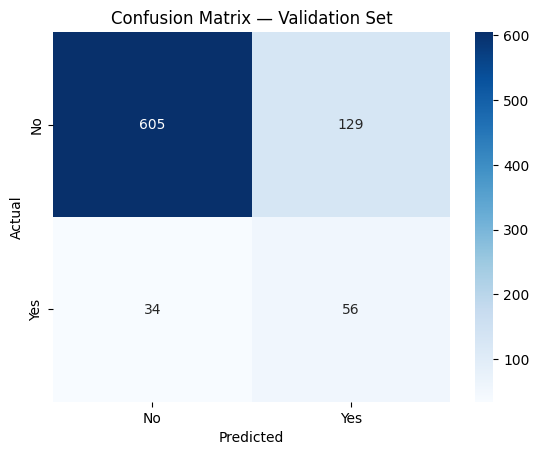

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Validation Set')
plt.show()

In [30]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred_adjusted = (y_pred_proba > 0.65).astype(int)
print(classification_report(y_val, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       734
           1       0.44      0.51      0.47        90

    accuracy                           0.88       824
   macro avg       0.69      0.72      0.70       824
weighted avg       0.88      0.88      0.88       824



/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


For the classification threshold, the default 0.5 was adjusted to 0.65 on the validation set. 0.65 and 0.7 were the boundaries where the decision seemed to be between. At the end 0.65 was selected over 0.7 because it had higher recall, and in this case the bank prefers flagging false positives over missing possibible subscribers. Therefore, in this case higher recall is prioritised